In [ ]:
#Installation of required packages
!pip install bioinfokit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import random
from bioinfokit.analys import get_data
from bioinfokit.visuz import cluster
import math
!pip install pHcalc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bioinfokit: filename=bioinfokit-2.1.4-py3-none-any.whl size=59221 sha256=00f59e9b1c6216bc4ce060fb4a5f917722bc3966b88681461fdd22181e8b77f7
  Stored in directory: /root/.cache/pip/wheels/45/b1/91/212510cab723ee76a25180836e8897f926820382374184b017
Successfully built bioinfokit


In [ ]:
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

In [ ]:
#Input Data
from google.colab import files
uploaded = files.upload()


Saving smiles_desc (1) (2).csv to smiles_desc (1) (2).csv


In [ ]:
data = pd.read_csv("smiles_desc (1) (2).csv")

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling only to the numerical columns
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [ ]:
print("\nScaled data:")
print(data.head())


Scaled data:
   Unnamed: 0     SMILES                                    XYZ Coordinates  \
0   -1.730591     CCCCCN  19\n10 10 10\nC   -2.9148   0.1059   -0.1724\n...   
1   -1.727670  Cc1ccncc1  14\n10 10 10\nC   1.9950   -0.0267   -0.0018\n...   
2   -1.724749    NCCOCCO  18\n10 10 10\nN   1.8101   1.3914   -0.1039\nC...   
3   -1.721829      CCNCC  16\n10 10 10\nC   2.2857   -0.2961   0.0335\nC...   
4   -1.718908      CCCCN  16\n10 10 10\nC   -2.2207   0.2788   0.1569\nC...   

                                                 ABC  \
0  module 'numpy' has no attribute 'float'.\n`np....   
1  module 'numpy' has no attribute 'float'.\n`np....   
2  module 'numpy' has no attribute 'float'.\n`np....   
3  module 'numpy' has no attribute 'float'.\n`np....   
4  module 'numpy' has no attribute 'float'.\n`np....   

                                               ABCGG  nAcid     nBase  \
0  module 'numpy' has no attribute 'float'.\n`np....    0.0 -0.625628   
1  module 'numpy' has no att

In [ ]:
data.to_csv("scaled_data.csv")
files.download('scaled_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Initialize PCA
n_components = 2  # Specify the number of principal components you want to keep
pca = PCA(n_components=n_components)


In [ ]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])

In [ ]:
# Fit and transform the scaled data
principal_components = pca.fit_transform(numeric_data)

In [ ]:
# Create a DataFrame for the principal components
pca_columns = [f"PC{i+1}" for i in range(n_components)]
pca_df = pd.DataFrame(data=principal_components, columns=pca_columns)


In [ ]:
from sklearn.cluster import KMeans
# Apply K-Means clustering
n_clusters = 3  # Set the number of clusters you want
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
clusters = kmeans.fit_predict(numeric_data)

In [ ]:
# Perform PCA
n_components = 2  # Number of principal components for visualization
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(numeric_data)

# Create a DataFrame for the principal components and clusters
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

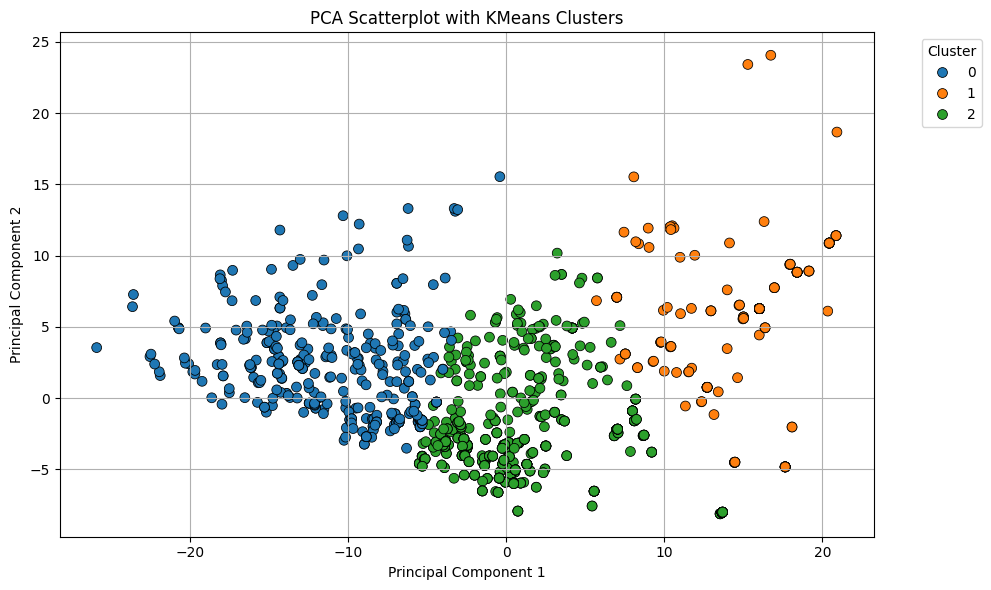

In [ ]:
# Add cluster labels to the PCA DataFrame
pca_df['Cluster'] = kmeans.labels_  # Assuming `kmeans.labels_` contains the cluster labels

# Scatterplot with clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",  # Color by cluster
    palette="tab10",  # Use a diverse color palette
    s=50,  # Marker size
    edgecolor="k",  # Black edge for better visibility
)
plt.title("PCA Scatterplot with KMeans Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
num_points = pca_df.shape[0]
print(num_points)

1186


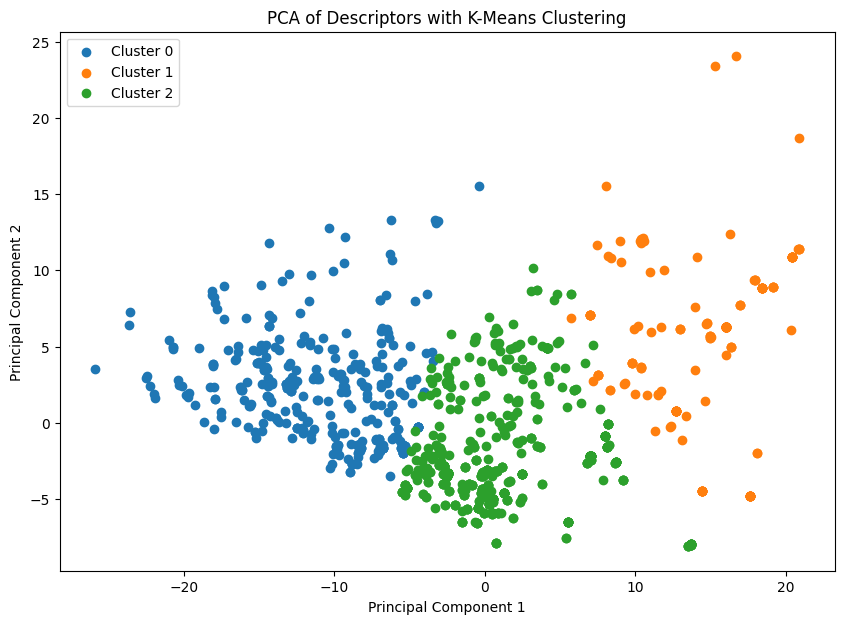

In [ ]:
# Plot the PCA components with clusters
plt.figure(figsize=(10, 7))
for cluster in range(n_clusters):
    cluster_points = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(cluster_points['PC1'], cluster_points['PC2'], label=f'Cluster {cluster}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Descriptors with K-Means Clustering')
plt.legend()
plt.show()

In [ ]:
data['Cluster'] = kmeans.fit_predict(numeric_data)

<ipython-input-30-6834a1ca2e90>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Cluster'] = kmeans.fit_predict(numeric_data)


In [ ]:
# Calculate the mean of each numeric descriptor within each cluster
numeric_data = data.select_dtypes(include=['float64', 'int64'])
numeric_data['Cluster'] = data['Cluster']  # Add cluster labels to the numeric data

# Calculate the mean for each cluster
cluster_means = numeric_data.groupby('Cluster').mean()

# Display top descriptors for each cluster by their mean values
for cluster in cluster_means.index:
    print(f"\nTop descriptors in Cluster {cluster} by mean value:")
    top_descriptors = cluster_means.loc[cluster].sort_values(ascending=False).head(5)
    print(top_descriptors)


Top descriptors in Cluster 0 by mean value:
VE2_D           1.132178
Mi              0.920328
FilterItLogS    0.857341
BalabanJ        0.819851
AMID_h          0.780258
Name: 0, dtype: float64

Top descriptors in Cluster 1 by mean value:
WPath      1.918140
SpAbs_D    1.908291
SpAD_D     1.908291
LogEE_D    1.905921
SpMax_D    1.905915
Name: 1, dtype: float64

Top descriptors in Cluster 2 by mean value:
GhoseFilter    0.560543
AMID_C         0.501255
piPC7          0.450715
piPC8          0.440347
MWC10          0.438381
Name: 2, dtype: float64


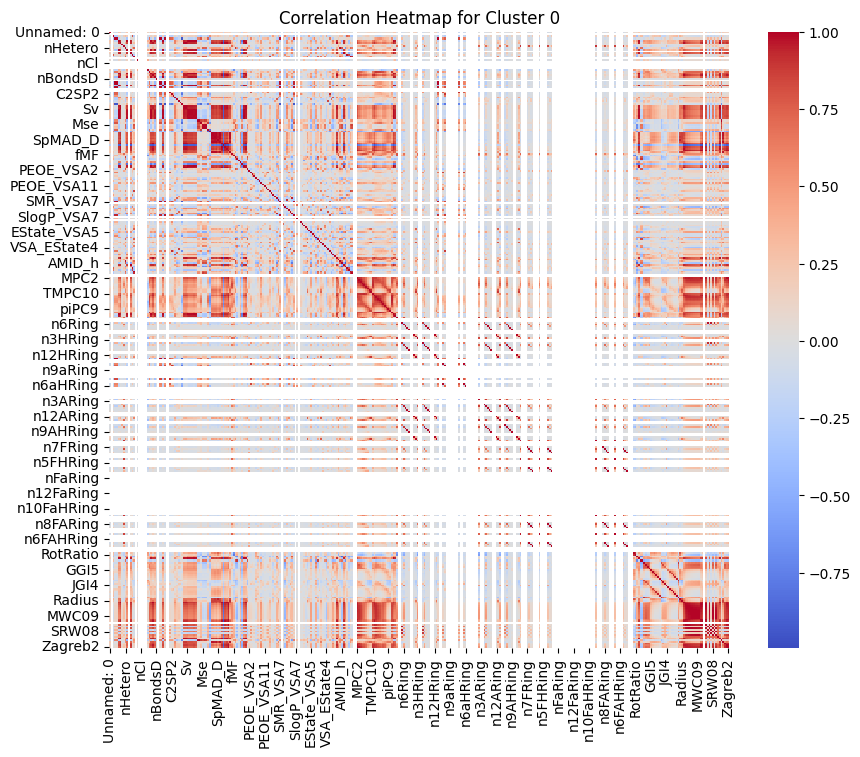

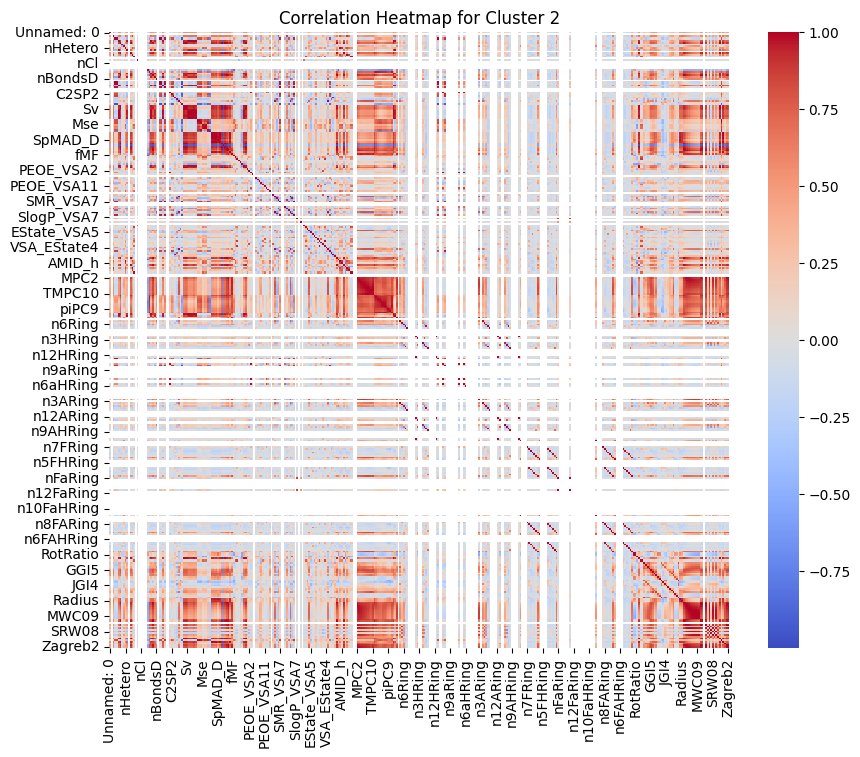

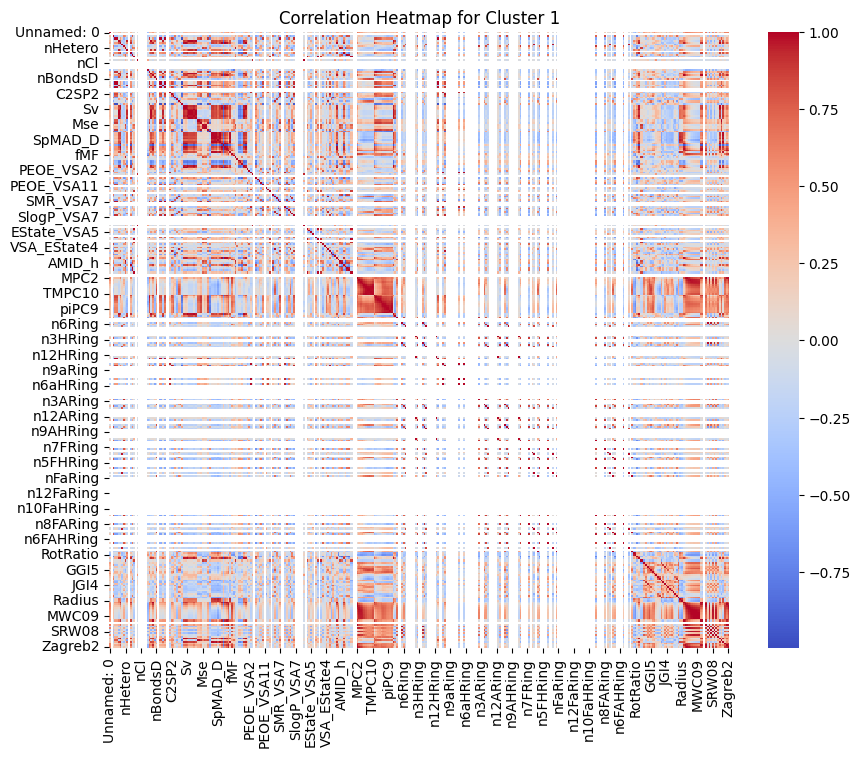

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a heatmap of correlations within each cluster
for cluster in data['Cluster'].unique():
    cluster_data = data[data['Cluster'] == cluster].select_dtypes(include=['float64', 'int64'])
    plt.figure(figsize=(10, 8))
    sns.heatmap(cluster_data.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlation Heatmap for Cluster {cluster}")
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA on the scaled data (assuming `scaled_data` is already created)
pca = PCA(n_components=3)  # Adjust the number of components as needed
pca.fit(numeric_data)

# Create a DataFrame for loadings
loadings = pd.DataFrame(pca.components_.T, index=numeric_data.columns, columns=['PC1', 'PC2', 'PC3'])

# Select the top descriptors (e.g., top 5 for each component) by absolute loading value
top_descriptors = loadings.apply(lambda x: x.abs().nlargest(5).index).values.flatten()
top_descriptors = pd.Index(top_descriptors).unique()  # Remove duplicates

# Filter the loadings DataFrame to include only the top descriptors
top_loadings = loadings.loc[top_descriptors]

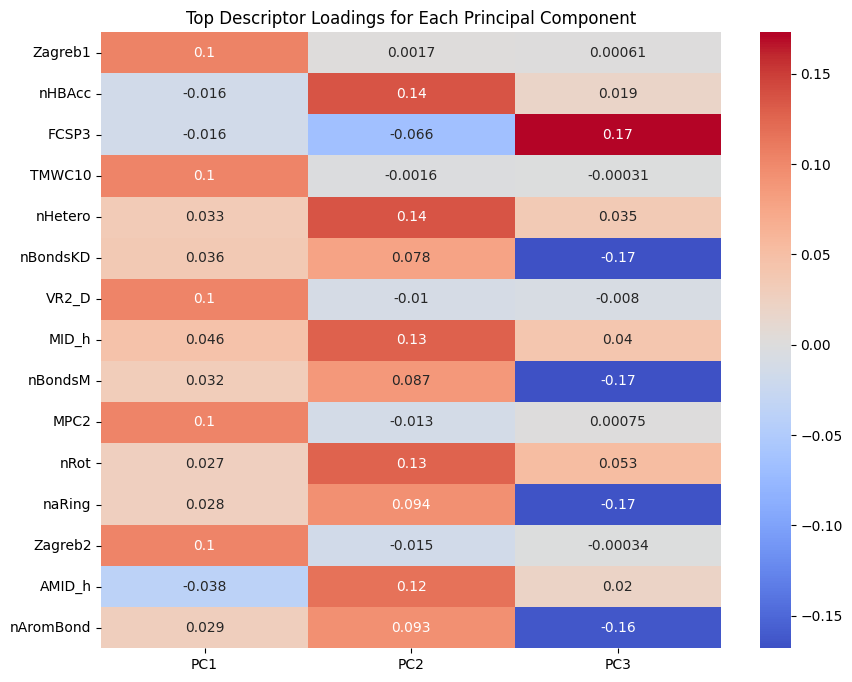

In [ ]:
# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_loadings, annot=True, cmap='coolwarm', center=0)
plt.title("Top Descriptor Loadings for Each Principal Component")
plt.show()